In [1]:
# ============================================================
# Cell 1 — Configuration
# Edit the variables below to explore a specific collection.
# ============================================================
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from dotenv import load_dotenv
load_dotenv(dotenv_path=os.path.join(os.getcwd(), "..", ".env"))

from scripts.config import (
    EMBEDDINGS_1887_COHERE,
    EMBEDDINGS_1887_OPENROUTER,
    COHERE_API_KEY,
    OPENROUTER_API_KEY,
    COHERE_EMBEDDING_MODEL,
    OPENROUTER_EMBEDDING_MODEL,
)

# --- USER SETTINGS ---
PROVIDER = "openrouter"          # "cohere" or "openrouter"
EMBEDDING_MODEL = "google/gemini-embedding-2-preview"           # None → use provider default
COLLECTION_NAME = "debattre_1887_10000_hierarchical_gemini-embedding-2-preview"  # name of the collection to explore
TOP_K = 5                        # number of results for query cell

# # Resolve defaults
# if EMBEDDING_MODEL is None:
#     EMBEDDING_MODEL = COHERE_EMBEDDING_MODEL if PROVIDER == "cohere" else OPENROUTER_EMBEDDING_MODEL

CHROMA_DIR = EMBEDDINGS_1887_COHERE if PROVIDER == "cohere" else EMBEDDINGS_1887_OPENROUTER

print(f"Provider  : {PROVIDER}")
print(f"Model     : {EMBEDDING_MODEL}")
print(f"Chroma dir: {CHROMA_DIR}")
print(f"Collection: {COLLECTION_NAME}")

Provider  : openrouter
Model     : google/gemini-embedding-2-preview
Chroma dir: c:\Users\user\Desktop\workdir\ORDER_EMNLP2026\data\embeddings_1887_openrouter
Collection: debattre_1887_10000_hierarchical_gemini-embedding-2-preview


In [2]:
# ============================================================
# Cell 2 — Load collection & preview
# ============================================================
import chromadb
from chromadb.utils import embedding_functions
from scripts.utils.embedding_functions import OpenRouterEmbeddingFunction

client = chromadb.PersistentClient(path=CHROMA_DIR)

if PROVIDER == "cohere":
    ef = embedding_functions.CohereEmbeddingFunction(
        api_key=COHERE_API_KEY, model_name=EMBEDDING_MODEL
    )
else:
    ef = OpenRouterEmbeddingFunction(api_key=OPENROUTER_API_KEY, model=EMBEDDING_MODEL)

In [3]:
collection = client.get_collection(name=COLLECTION_NAME, embedding_function=ef)
print(f"Collection '{COLLECTION_NAME}' loaded — {collection.count()} documents")
print(f"Metadata  : {collection.metadata}")

# Show 5 sample documents
sample = collection.get(limit=5, include=["documents", "metadatas"])
for i, (doc, meta) in enumerate(zip(sample["documents"], sample["metadatas"])):
    print(f"\n--- Sample {i+1} | id={sample['ids'][i]} | meta={meta} ---")
    print(doc[:300], "..." if len(doc) > 300 else "")

Collection 'debattre_1887_10000_hierarchical_gemini-embedding-2-preview' loaded — 5103 documents
Metadata  : {'description': 'Embeddings of the Débats parlementaires 1887 corpus split hierarchically with a threshold of 10 000 chars using openrouter/google/gemini-embedding-2-preview', 'model': 'google/gemini-embedding-2-preview', 'provider': 'openrouter'}

--- Sample 1 | id=1887-01-11_000_000.txt | meta={'month': '01', 'year': '1887', 'day': '11', 'base_name': '1887-01-11_000_000.txt'} ---
.

IrDEBATS PARLEMENTAIRES 

--- Sample 2 | id=1887-01-11_001_000.txt | meta={'base_name': '1887-01-11_001_000.txt', 'month': '01', 'day': '11', 'year': '1887'} ---
COMPTE RENDU IN EXTENSO

Séance du Mardi 11 Janvier 1887 

--- Sample 3 | id=1887-01-11_002_000.txt | meta={'month': '01', 'year': '1887', 'day': '11', 'base_name': '1887-01-11_002_000.txt'} ---
SOMMAIRE Installation du président d'âge et des secrétai.

res d'âge.

Allocution de M. Pierre Blanc, président d'âge.

Demandes de congés. ■Tirag

In [4]:
# ============================================================
# Cell 3 — Semantic query
# ============================================================
import pandas as pd

QUERY = "Boulanger est une menace pour la République"

results = collection.query(
    query_texts=[QUERY],
    n_results=TOP_K,
    include=["documents", "metadatas", "distances"],
)

rows = []
for rank, (doc, meta, dist) in enumerate(
    zip(results["documents"][0], results["metadatas"][0], results["distances"][0]), 1
):
    rows.append({"rank": rank, "distance": round(dist, 4), **meta, "text_preview": doc[:200]})

df_results = pd.DataFrame(rows)
print(f"Query: {QUERY!r}")
df_results

Query: 'Boulanger est une menace pour la République'


,rank,distance,month,year,base_name,day,text_preview
0,1,1.0834,05,1887,1887-05-17_007_000.txt,17,PRÉSENTATION D'UN PROJET DE LOI M. le général ...
1,2,1.0858,03,1887,1887-03-05_007_000.txt,05,PRÉSENTATION D'UN PROJET DE LOI\n\n! M. le pré...
2,3,1.1012,05,1887,1887-05-10_009_000.txt,10,PRÉSENTATION D'UN PROJET DE 101 M. le présiden...
3,4,1.1115,03,1887,1887-03-30_007_013.txt,30,Il y a ici un grand nombre d'hommes absolument...
4,5,1.1169,05,1887,1887-05-23_929_003.txt,23,1uepuislewule patriotisme en France est devenu...


In [5]:
# ============================================================
# Cell 4 — Browse by date
# ============================================================
YEAR_FILTER  = "1887"   # set to None to skip
MONTH_FILTER = "11"     # set to None to skip

where_clauses = {}
if YEAR_FILTER:
    where_clauses["year"] = YEAR_FILTER
if MONTH_FILTER:
    where_clauses["month"] = MONTH_FILTER

if where_clauses:
    if len(where_clauses) == 1:
        where = where_clauses
    else:
        where = {"$and": [{k: v} for k, v in where_clauses.items()]}
    results_date = collection.get(where=where, include=["documents", "metadatas"])
else:
    results_date = collection.get(limit=20, include=["documents", "metadatas"])

print(f"Docs matching filter {where_clauses}: {len(results_date['ids'])}")
rows_date = []
for doc, meta in zip(results_date["documents"], results_date["metadatas"]):
    rows_date.append({**meta, "text_preview": doc[:200]})
pd.DataFrame(rows_date)

Docs matching filter {'year': '1887', 'month': '11'}: 503


,day,month,base_name,year,text_preview
0,03,11,1887-11-03_000_000.txt,1887,.
1,03,11,1887-11-03_001_000.txt,1887,CHAMBRE DES DÉPUTÉSSession extraordinaire do 1...
2,03,11,1887-11-03_002_000.txt,1887,COIPTI RENDU IN EXTENSO. — 48 SÉANCE Séance du...
3,03,11,1887-11-03_003_000.txt,1887,"SOMMAIRE Procès-verbal: MM. Gillet, Boucher et..."
4,03,11,1887-11-03_004_000.txt,1887,EXCUSES ET DEMANDES DE CONGÉ M. le président. ...
...,...,...,...,...,...
498,28,11,1887-11-28_004_000.txt,1887,PRÉSIDENCE DE M. CHARLES FLOQUBT La séance est...
499,28,11,1887-11-28_005_000.txt,1887,DÉPÔT DE RAPPORTS M. Yves-Guyot. J'ai l'honneu...
500,28,11,1887-11-28_006_000.txt,1887,EXCUSE
501,28,11,1887-11-28_007_000.txt,1887,— DEMANDES DE CONGÉ M. le président. M. Chevan...


Total documents: 5103


,year,month,count
0,1887,01,545
1,1887,02,691
2,1887,03,796
3,1887,04,127
4,1887,05,2042
5,1887,10,155
6,1887,11,503
7,1887,12,244


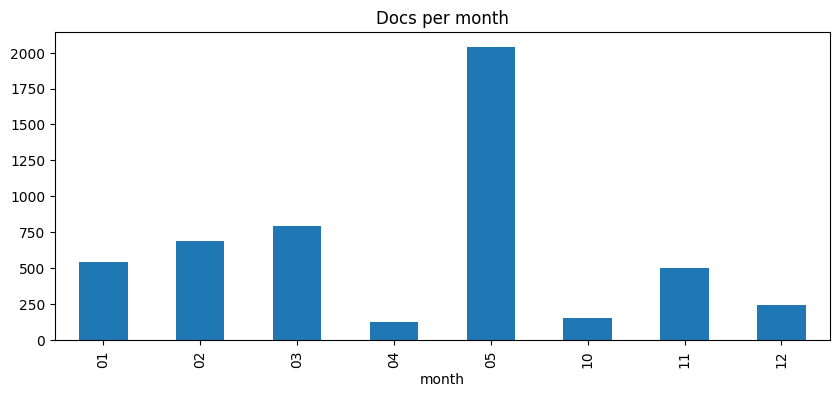

In [6]:
# ============================================================
# Cell 5 — Stats: document count by year/month
# ============================================================
all_metas = collection.get(include=["metadatas"])["metadatas"]
df_meta = pd.DataFrame(all_metas)
print(f"Total documents: {len(df_meta)}")
if "year" in df_meta.columns and "month" in df_meta.columns:
    counts = (
        df_meta.groupby(["year", "month"])
        .size()
        .reset_index(name="count")
        .sort_values(["year", "month"])
    )
    display(counts)
    counts.plot.bar(x="month", y="count", title="Docs per month", figsize=(10, 4), legend=False)
else:
    print("No year/month metadata found")
    print(df_meta.head())